<div class="output_png output_subarea output_execute_result">
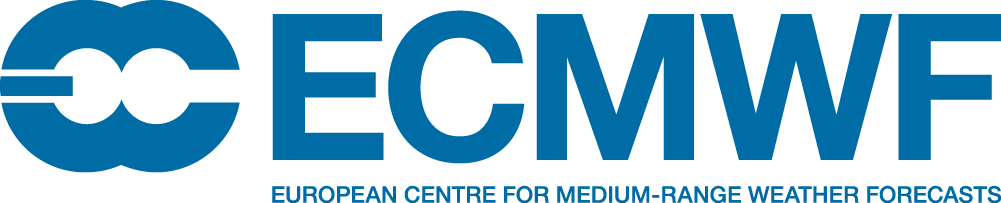
</div>

# 	Probabilities: 10 m wind gust (day 10-15)

This notebook will provide you guidance how to explore and plot ECMWF open dataset to produce the map from the ECMWF open charts web product.  
The original product can be found on this link: https://charts.ecmwf.int/products/medium-wg-long-probability  


<div class="output_png output_subarea output_execute_result">
<center>
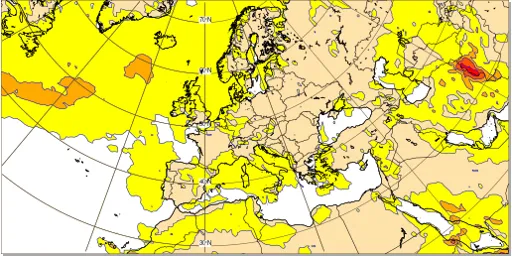</center>
</div>

The full list of available Open data products can be found [here](https://www.ecmwf.int/en/forecasts/datasets/open-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF Open data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain the access to the full forecast dataset at higher resolution please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes in input 3 parameters :

* [10 metre wind gust of at least 10 m/s](https://codes.ecmwf.int/grib/param-db/131100)
* [10 metre wind gust of at least 15 m/s](https://codes.ecmwf.int/grib/param-db/131070)
* [10 metre wind gust of at least 25 m/s](https://codes.ecmwf.int/grib/param-db/131072)

In this example, we will use: 
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data 

First we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-opendata

In [1]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [2]:
client = Client("ecmwf", beta=False)

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


In [3]:
parameters = ['10fgg10','10fgg15', '10fgg25']
filename = 'medium-wg-long-probability.grib'
filename

'medium-wg-long-probability.grib'

<div class="alert alert-block alert-success">
Note that this parameter has a slightly different step than most of the other parameters.  
Since this parameter is the probability for the wind gust larger than a threshold in a 24-hour period, the step is interval between the beginning and the end of the period. We retrieve five 24-hour intervals to get days 10-15.
</div>

In [4]:
client.retrieve(
    date=-1,
    time=0,
    step=["240-264", "264-288", "288-312", "312-336", "336-360"],
    stream="enfo",
    type="ep",
    levtype="sfc",
    param=parameters,
    target=filename
)

20260802000000-360h-enfo-ep.grib2:   0%|          | 0.00/5.42M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


In [5]:
data = mv.read(filename)

The **describe()** function will give us the overview of the dataset.  

In [6]:
data.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
10fgg10,heightAboveGround,10,20260802,0,"264,288,...",None,131100,od,enfo,ep,0001
10fgg15,heightAboveGround,10,20260802,0,"264,288,...",None,131070,od,enfo,ep,0001
10fgg25,heightAboveGround,10,20260802,0,"264,288,...",None,131072,od,enfo,ep,0001


We can use **ls()** function to list all the fields in the file we downloaded.

In [7]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
Message,,,,,,,,,,
0,ecmf,10fgg15,heightAboveGround,10,20260802,0,240-264,ep,None,regular_ll
1,ecmf,10fgg15,heightAboveGround,10,20260802,0,264-288,ep,None,regular_ll
2,ecmf,10fgg15,heightAboveGround,10,20260802,0,288-312,ep,None,regular_ll
3,ecmf,10fgg15,heightAboveGround,10,20260802,0,312-336,ep,None,regular_ll
4,ecmf,10fgg15,heightAboveGround,10,20260802,0,336-360,ep,None,regular_ll
5,ecmf,10fgg25,heightAboveGround,10,20260802,0,240-264,ep,None,regular_ll
6,ecmf,10fgg25,heightAboveGround,10,20260802,0,264-288,ep,None,regular_ll
7,ecmf,10fgg10,heightAboveGround,10,20260802,0,240-264,ep,None,regular_ll
8,ecmf,10fgg25,heightAboveGround,10,20260802,0,288-312,ep,None,regular_ll


The grib file contains all the parameters, and we will use the **select()** function to filter one of them.  
Select **10fgg15** for a 10-metre wind gust of at least 15 m/s, or **10fgg25** for a 10-metre wind gust of at least 25 m/s.

In [8]:
fgg15 = data.select(shortName= "10fgg15")
fgg15.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
10fgg15,heightAboveGround,10,20260802,0,"264,288,...",None,131070,od,enfo,ep,0001


Then, we find a max probability over all time steps.

In [9]:
fgg15_prob = mv.max(fgg15)

## Plotting the data
And finally, we can plot the data on the map. 

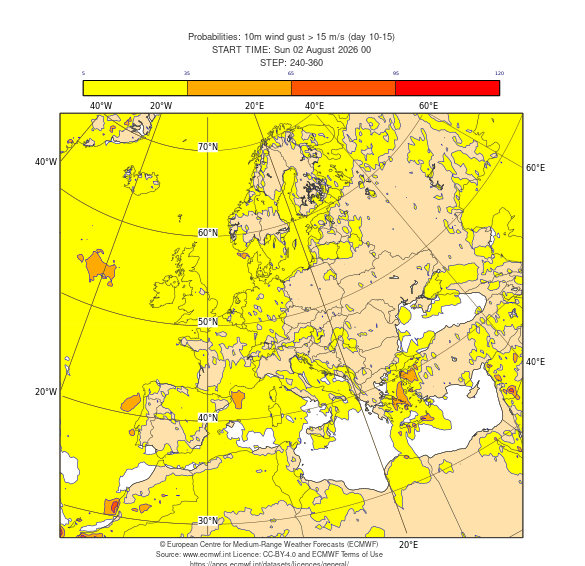

In [11]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
fgg15_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_red_f0t100lst")

title = mv.mtext(
    text_lines=["Probabilities: 10m wind gust > 15 m/s (day 10-15)", 
               "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H' /> ", 
               "STEP: 240-360"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, fgg15_prob, fgg15_shade, title, ecmwf_text)

To generate the png file you can run the following cell.

In [12]:
png = mv.png_output(
      output_name = "medium-wg-long-probability",   # specify relative or full path
      output_title = "medium-wg-long-probability",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, fgg15_prob, fgg15_shade, title, ecmwf_text)

Note that plot produced using open data dataset will slightly differ from one from Open Charts. This is due to different resolution of the data.  
Open data is on 0.25x0.25 resolution, while high resolution data is 0.1x0.1 grid.